# Código da base do projeto

Para realização deste projeto pegamos uma parte do datset desenvolvido no capítulo passado. O objetivo do modelo é com base na descrição dos sintomas do passiente retornar a possivel doença ou pedir mais exames ao paciente caso não consiga classificar a doença. Além de classificar a doença o algoritmo foi treinado com uma base pequena de dados para dizer se a doença tem risco baixo ou alto.

In [2]:
import pandas as pd

# Carregar mapa de conhecimento
mapa_conhecimento = pd.read_csv('mapa_conhecimento.csv')

# Ler as frases do arquivo .txt
with open('Sintomas.txt', 'r', encoding='utf-8') as f:
    frases_pacientes = f.readlines()

def sugerir_diagnostico(frase, mapa):
    frase = frase.lower()
    for _, row in mapa.iterrows():
        # Lógica simples de busca por palavras-chave
        if row['Sintoma 1'].lower() in frase or row['Sintoma 2'].lower() in frase:
            return row['Doença Associada']
    return "Diagnóstico inconclusivo - Necessário exames complementares"

print("--- Diagnósticos Automatizados (CardioIA) ---")
for i, frase in enumerate(frases_pacientes):
    diagnostico = sugerir_diagnostico(frase, mapa_conhecimento)
    print(f"Paciente {i+1}: {frase.strip()}")
    print(f"Sugestão de Diagnóstico: {diagnostico}\n")

--- Diagnósticos Automatizados (CardioIA) ---
Paciente 1: ﻿Sinto uma dor aguda no peito que irradia para o braço esquerdo há 30 minutos.
Sugestão de Diagnóstico: Diagnóstico inconclusivo - Necessário exames complementares

Paciente 2: Estou com um cansaço constante e fadiga extrema mesmo sem fazer esforço físico.
Sugestão de Diagnóstico: Insuficiência Cardíaca

Paciente 3: Percebi que sinto muita falta de ar e dificuldade para respirar ao subir escadas.
Sugestão de Diagnóstico: Angina

Paciente 4: Tenho sentido um aperto forte no tórax que piora quando estou estressado.
Sugestão de Diagnóstico: Diagnóstico inconclusivo - Necessário exames complementares

Paciente 5: Sinto palpitações e batimentos irregulares no coração desde ontem à noite.
Sugestão de Diagnóstico: Arritmia

Paciente 6: Minhas pernas estão muito inchadas e sinto um peso constante no final do dia.
Sugestão de Diagnóstico: Diagnóstico inconclusivo - Necessário exames complementares

Paciente 7: Tive um episódio de desmaio

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Carregar dados
df = pd.read_csv('dataset_risco.csv')

# 2. Pré-processamento e Vetorização (TF-IDF)
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['Frase'])
y = df['Situação']

# 3. Divisão Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Treinamento do Modelo (Logistic Regression)
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

# 5. Avaliação
y_pred = modelo.predict(X_test)
print("--- Avaliação do Classificador de Risco ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred)}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

# 6. Teste Prático
frase_teste = ["Sinto um aperto insuportável no coração"]
vetor_teste = vectorizer.transform(frase_teste)
previsao = modelo.predict(vetor_teste)
print(f"\nTeste de frase: '{frase_teste[0]}'")
print(f"Classificação: {previsao[0]}")

--- Avaliação do Classificador de Risco ---
Acurácia: 0.875

Relatório de Classificação:
              precision    recall  f1-score   support

  alto risco       1.00      0.75      0.86         4
 baixo risco       0.80      1.00      0.89         4

    accuracy                           0.88         8
   macro avg       0.90      0.88      0.87         8
weighted avg       0.90      0.88      0.87         8



IndexError: list index out of range

# Ir além 2
Para fazer o ir além 2 utilizams a ajudas externas de algumas Inteligências Artificiais para conseguir fazer e estudar modelos corretos e com alta acertividade, separamos o melhor modelo treinado pelo grupo usando o dataset recomendado pela FIAP para essa etapa. O modelo representa uma acurácia superior a 95%, sem overfitting.

--- Localizando Dataset ---
Using Colab cache for faster access to the 'heartbeat' dataset.
--- Configurando a MLP Robusta ---
--- Iniciando Treinamento ---
Epoch 1/25
685/685 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.9362 - loss: 0.1886 - val_accuracy: 0.9553 - val_loss: 0.1330
Epoch 2/25
685/685 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9567 - loss: 0.1337 - val_accuracy: 0.9663 - val_loss: 0.1099
Epoch 3/25
685/685 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9611 - loss: 0.1204 - val_accuracy: 0.9642 - val_loss: 0.1081
Epoch 4/25
685/685 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9638 - loss: 0.1113 - val_accuracy: 0.9693 - val_loss: 0.0960
Epoch 5/25
685/685 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9662 - loss: 0.1050 - val_accuracy: 0.9723 - val_loss: 0.0906
Epoch 6/25
685/685 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9690 - loss: 0.0990 - val_accuracy: 0.9720 - val_loss: 0.0859
Epoch 7/25
685/685 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.

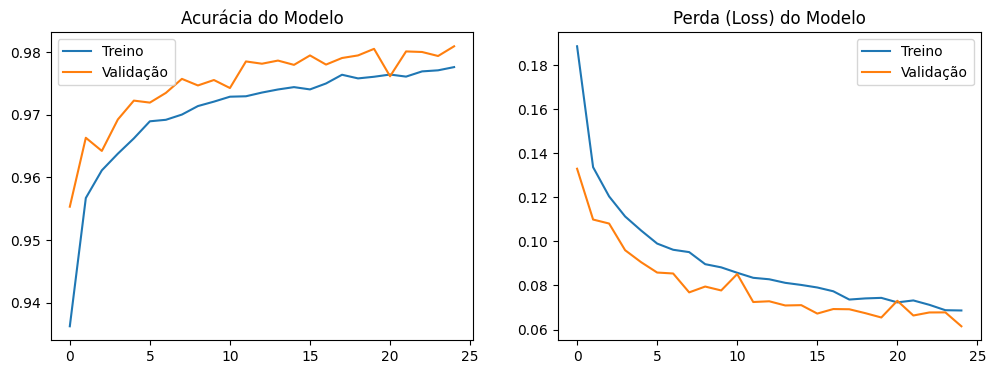

In [10]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from tensorflow.keras import layers, models

# 1. Baixando o dataset
print("--- Localizando Dataset ---")
path = kagglehub.dataset_download("shayanfazeli/heartbeat")

train_path = os.path.join(path, 'mitbih_train.csv')
test_path = os.path.join(path, 'mitbih_test.csv')

# 2. Carregando e embaralhando o dataset
train_df = pd.read_csv(train_path, header=None)
test_df = pd.read_csv(test_path, header=None)

train_df = shuffle(train_df, random_state=42)
test_df = shuffle(test_df, random_state=42)

# 3. Função de preparação (normal x anormal)
def prepare_data(df):
    X = df.iloc[:, :187].values
    y = df.iloc[:, 187].values
    y_binary = (y > 0).astype(int) # dentre os valores o 0 = normal e 0 > anormal
    X = X / np.max(X) if np.max(X) != 0 else X
    return X, y_binary

X_train, y_train = prepare_data(train_df)
X_test, y_test = prepare_data(test_df)

# 4. Arquitetura da Rede
print("--- Configurando a MLP Robusta ---")
model = models.Sequential([
    layers.Input(shape=(187,)),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 5. Treinamento
print("--- Iniciando Treinamento ---")
history = model.fit(X_train, y_train,
                    epochs=25,
                    batch_size=128,
                    validation_data=(X_test, y_test),
                    verbose=1)

# 6. Visualisando os dados
print("\n--- Gerando Gráficos de Performance ---")
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia do Modelo')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Perda (Loss) do Modelo')
plt.legend()

plt.show()